<a href="https://colab.research.google.com/github/isaevadaryna/Machine-Learning/blob/main/%D0%9B%D0%B0%D0%B1_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [5]:
sheet_url = "https://docs.google.com/spreadsheets/d/1_0JYPQGKD13cCdE-2v9NrPyfduW1MiYcHMskmOBDbX4/export?format=csv"
df = pd.read_csv(sheet_url)

# Перевіримо перші рядки
df.head()


,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


In [6]:
# Вибираємо лише числові колонки
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Заповнюємо пропуски середнім значенням
df_numeric = df[numeric_cols].fillna(df[numeric_cols].mean())

df_numeric.head()


,case,site,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


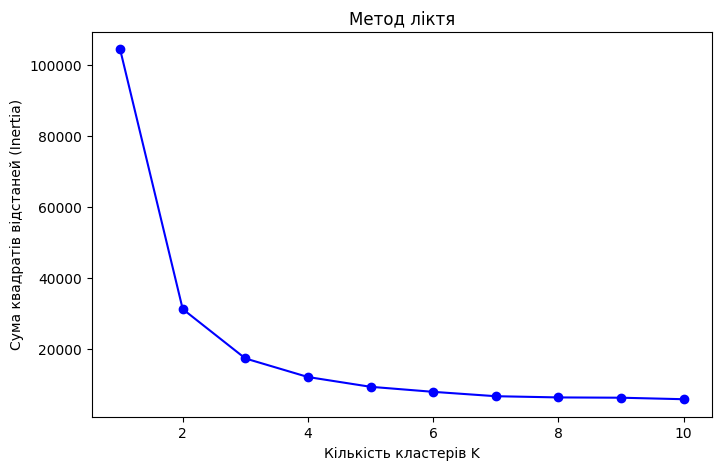

In [7]:
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_numeric)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Кількість кластерів K')
plt.ylabel('Сума квадратів відстаней (Inertia)')
plt.title('Метод ліктя')
plt.show()


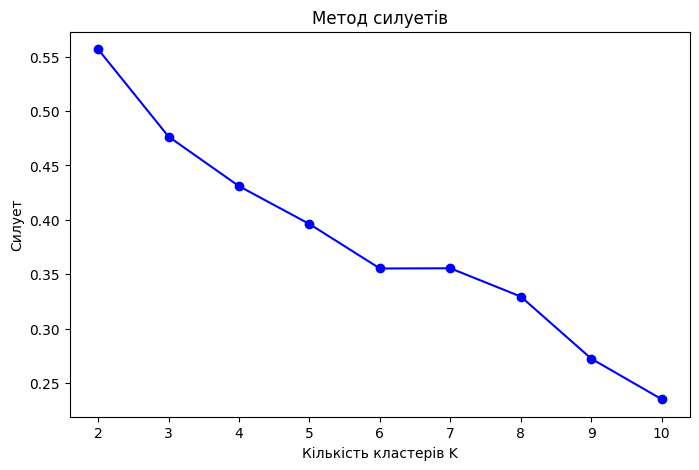

In [8]:
silhouette_scores = []
K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_numeric)
    score = silhouette_score(df_numeric, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(K, silhouette_scores, 'bo-')
plt.xlabel('Кількість кластерів K')
plt.ylabel('Силует')
plt.title('Метод силуетів')
plt.show()


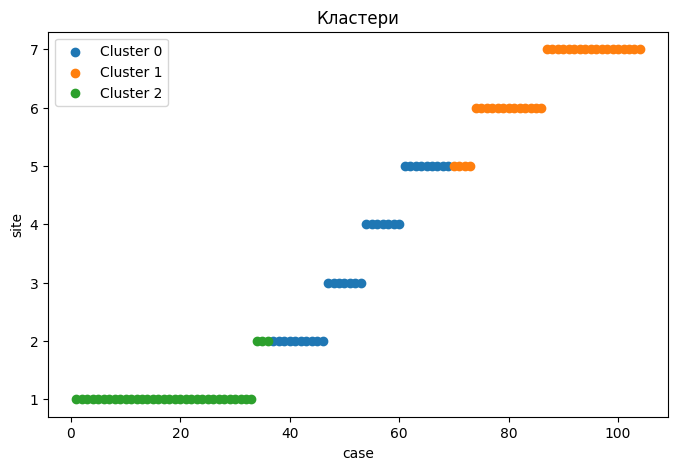

In [9]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(df_numeric)
df['Cluster'] = labels  # додаємо колонку кластерів до оригінального датасету

# Візуалізація перших двох числових колонок
plt.figure(figsize=(8,5))
for cluster in range(3):
    plt.scatter(df_numeric.iloc[labels==cluster, 0],
                df_numeric.iloc[labels==cluster, 1],
                label=f'Cluster {cluster}')
plt.xlabel(df_numeric.columns[0])
plt.ylabel(df_numeric.columns[1])
plt.legend()
plt.title('Кластери')
plt.show()
